In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

In [21]:
def debt_to_farm_asset_ratio(P, L, W, tcs=0.06, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    lafa = (W / (pps * L)) - 1.0
    return max(0.0, -lafa)
    

def resulting_dfa_after_trade(P, L, W, x, xm=0.0, tcs=0.06, tcb=0.01, fds=0.07, fme=300.0):
    """Compute resulting DFA after farmland trade and mutual-fund investment."""
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    ppps = (1.0 + tcb) * P + fme
    if x < 0:
        ppps = pps
    L_post = L + x
    if L_post <= 0.0:
        return 0.0
    # Account for mutual-fund investment reducing effective wealth
    lafa12f = (W - xm - pps * L - ppps * x) / (pps * L_post)
    return max(0.0, -lafa12f)


In [44]:
from dataclasses import dataclass

import numpy as np

from dynprolib.pyfriendly import PortfolioConfig
from dynprolib.pyfriendly.portfolio_core import (
    apply_inverse_basis_chain,
    build_model_arrays,
    cartesian_grid,
    gauss_hermite_multinormal,
    linear_spline_basis,
    model_inverse_utility,
    model_utility,
    tensor_basis_interpolate,
    uniform_nodes,
)


@dataclass
class MutualFundConfig(PortfolioConfig):
    theta: float = 1.0
    gamma0: float = 0.057757
    EgRM: float = 1.073826
    n: tuple[int, int, int, int] = (7, 7, 5, 21)
    q: int = 41
    q2: int = 25
    qf: int = 21
    search_mode: str = "matlab"
    value_backend: str = "no" #"numba"
    q_batch: int = 4
    q_batch_max_rows: int = 100_000
    q_coarse_step: int = 4
    q_refine_radius: int = 2
    q2_batch_max_rows: int = 100_000
    q2_batch: int = 4
    q2_refine_radius: int = 2
    m: tuple[int, int, int] = (3, 3, 3)
    var_cov: tuple[tuple[float, float, float], tuple[float, float, float], tuple[float, float, float]] = (
        (0.030186, 0.0, 0.0),
        (0.0, 0.017292, 0.0),
        (0.0, 0.0, 0.026941),
    )


def mutual_bounds_x(state, cfg):
    state = np.asarray(state, dtype=float)
    x_lower = np.full(state.shape[0], cfg.sminv[2], dtype=float) - state[:, 2]
    x_upper_land = np.full(state.shape[0], cfg.smaxv[2], dtype=float) - state[:, 2]
    sell_price = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    x_upper_debt = np.maximum(
        0.0,
        (state[:, 3] - (1.0 - cfg.dau) * sell_price * state[:, 2]) / (buy_price - cfg.dau * sell_price),
    )
    return x_lower, np.minimum(x_upper_land, x_upper_debt)


def mutual_bounds_xm(state, trade_x, cfg):
    state = np.asarray(state, dtype=float)
    trade_x = np.asarray(trade_x, dtype=float)
    if np.isscalar(trade_x):
        trade_x = np.full(state.shape[0], float(trade_x), dtype=float)
    if np.all(state[:, 2] + trade_x < 1.0):
        xml = state[:, 3].copy()
        xmu = state[:, 3].copy()
        return xml, xmu

    s2bs = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    s2bs[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme
    s2v = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    at = state[:, 3] - s2v * state[:, 2]
    xml = np.zeros(state.shape[0], dtype=float)
    xmu = np.maximum(0.0, at - s2bs * trade_x + cfg.dau * s2v * (state[:, 2] + trade_x))
    return xml, xmu


def mutual_transition_next_state(state, trade_x, mutual_x, shocks, cfg, sminv, smaxv):
    state = np.asarray(state, dtype=float)
    trade_x = np.asarray(trade_x, dtype=float)
    mutual_x = np.asarray(mutual_x, dtype=float)
    shocks = np.asarray(shocks, dtype=float)
    next_state = np.zeros_like(state, dtype=float)

    growth_r = np.exp(cfg.beta0 + cfg.beta1 * np.log(state[:, 0]) + shocks[:, 0])
    growth_p = np.exp(cfg.alpha0 + cfg.alpha1 * np.log(state[:, 1]) + cfg.alpha2 * np.log(state[:, 0]) + shocks[:, 1])
    growth_m = np.exp(cfg.gamma0 + shocks[:, 2])

    next_state[:, 0] = np.clip(growth_r, sminv[0], smaxv[0])
    next_state[:, 1] = np.clip(growth_p, sminv[1], smaxv[1])
    next_state[:, 2] = state[:, 2] + trade_x

    sell_price_now = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    sell_price_next = (1.0 - cfg.tcs) * next_state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme

    equity_now = state[:, 3] - sell_price_now * state[:, 2]
    low_land = next_state[:, 2] < 1.0

    if np.all(low_land):
        next_state[:, 3] = cfg.EgRM * state[:, 3]
        return next_state

    cash_after_cost = equity_now - buy_price * trade_x - cfg.cost * next_state[:, 2] - mutual_x
    rate_high_land = np.full(state.shape[0], cfg.rp, dtype=float)
    rate_high_land[cash_after_cost < 0] = cfg.rn
    wealth_high_land = (1.0 + rate_high_land) * cash_after_cost + next_state[:, 0] * next_state[:, 2] + sell_price_next * next_state[:, 2] + growth_m * mutual_x

    next_state[:, 3] = wealth_high_land
    return next_state


def _search_mode(cfg):
    return str(getattr(cfg, 'search_mode', 'matlab')).lower()


def _value_backend(cfg):
    return str(getattr(cfg, 'value_backend', 'numba')).lower()


from numba import njit


@njit(cache=True)
def _numba_exit_value_scalar(w, t, T, EgRM, gamma0, b, theta, crra):
    if crra and theta == 1.0:
        ww = w if w > 1e-12 else 1e-12
        return np.log(ww) + gamma0 * (T - t + 1)
    return _numba_model_utility_scalar((EgRM ** (T - t + 1)) * w, b, theta, crra)


@njit(cache=True)
def _numba_model_utility_scalar(y, b, theta, crra):
    if not crra:
        if theta <= 0.0:
            return np.nan
        if b > 0.0:
            u_b = 1.0 - np.exp(-theta * b)
            slope = theta * np.exp(-theta * b)
            if y >= b:
                return 1.0 - np.exp(-theta * y)
            return u_b + slope * (y - b)
        return 1.0 - np.exp(-theta * y)

    if theta == 0.0:
        return y
    if theta == 1.0:
        if y >= b:
            return np.log(y if y > 1e-12 else 1e-12)
        return (np.log(b) / b) * y
    return np.nan


@njit(cache=True)
def _numba_mutual_value_function_no_coeffs(
    state,
    trade_x,
    mutual_x,
    t,
    T,
    EgRM,
    beta0,
    beta1,
    alpha0,
    alpha1,
    alpha2,
    gamma0,
    b,
    theta,
    crra,
    tcs,
    tcb,
    fds,
    fme,
    rp,
    rn,
    cost,
    shock_nodes,
    shock_weights,
):
    n_states = state.shape[0]
    n_shocks = shock_nodes.shape[0]
    value = np.zeros(n_states, dtype=np.float64)
    cont_factor = EgRM ** (T - t + 1)

    for i in range(n_states):
        L = state[i, 2]
        W = state[i, 3]
        x = trade_x[i]
        xm = mutual_x[i]

        if L + x < 1.0:
            value[i] = _numba_exit_value_scalar(W, t, T, EgRM, gamma0, b, theta, crra)
            continue

        acc = 0.0
        R = state[i, 0]
        P = state[i, 1]
        sell_price_now = (1.0 - tcs) * P + (1.0 - fds) * fme
        buy_price = (1.0 + tcb) * P + fme
        if x < 0.0:
            buy_price = sell_price_now
        equity_now = W - sell_price_now * L
        land_post = L + x
        cash_after_cost = equity_now - buy_price * x - cost * land_post - xm
        rate_high_land = rp if cash_after_cost >= 0.0 else rn

        for k in range(n_shocks):
            growth_r = np.exp(beta0 + beta1 * np.log(R) + shock_nodes[k, 0])
            growth_p = np.exp(alpha0 + alpha1 * np.log(P) + alpha2 * np.log(R) + shock_nodes[k, 1])
            growth_m = np.exp(gamma0 + shock_nodes[k, 2])
            sell_price_next = (1.0 - tcs) * growth_p + (1.0 - fds) * fme

            if land_post < 1.0:
                vk = _numba_model_utility_scalar(cont_factor * W, b, theta, crra)
            else:
                next_W = (1.0 + rate_high_land) * cash_after_cost + growth_r * land_post + sell_price_next * land_post + growth_m * xm
                vk = _numba_model_utility_scalar(next_W, b, theta, crra)
            acc += shock_weights[k] * vk

        value[i] = acc

    return value


@njit(cache=True)
def _numba_model_inverse_utility_scalar(u, b, theta, crra):
    if not crra:
        if theta <= 0.0:
            return np.nan
        if b > 0.0:
            u_b = 1.0 - np.exp(-theta * b)
            slope = theta * np.exp(-theta * b)
            if u >= u_b:
                one_minus_u = 1.0 - u
                if one_minus_u < 1e-300:
                    one_minus_u = 1e-300
                return -np.log(one_minus_u) / theta
            denom = slope if slope > 1e-300 else 1e-300
            return b + (u - u_b) / denom
        one_minus_u = 1.0 - u
        if one_minus_u < 1e-300:
            one_minus_u = 1e-300
        return -np.log(one_minus_u) / theta

    if theta == 0.0:
        return u
    if theta == 1.0:
        if u >= np.log(b):
            return np.exp(u)
        return (b / np.log(b)) * u
    return np.nan


@njit(cache=True)
def _numba_linear_basis_idx_weight(n, a, b, x):
    h = (b - a) / (n - 1)
    idx = int(np.floor((x - a) / h))
    if idx < 0:
        idx = 0
    elif idx > n - 2:
        idx = n - 2
    left = a + h * idx
    right = a + h * (idx + 1)
    span = right - left
    if span < 1e-12:
        span = 1e-12
    w_right = (x - left) / span
    if w_right < 0.0:
        w_right = 0.0
    elif w_right > 1.0:
        w_right = 1.0
    return idx, w_right


@njit(cache=True)
def _numba_interp4_linear(coeffs, n, smin, smax, x0, x1, x2, x3):
    n0 = int(n[0])
    n1 = int(n[1])
    n2 = int(n[2])
    n3 = int(n[3])

    i0, wr0 = _numba_linear_basis_idx_weight(n0, smin[0], smax[0], x0)
    i1, wr1 = _numba_linear_basis_idx_weight(n1, smin[1], smax[1], x1)
    i2, wr2 = _numba_linear_basis_idx_weight(n2, smin[2], smax[2], x2)
    i3, wr3 = _numba_linear_basis_idx_weight(n3, smin[3], smax[3], x3)

    wl0 = 1.0 - wr0
    wl1 = 1.0 - wr1
    wl2 = 1.0 - wr2
    wl3 = 1.0 - wr3

    n23 = n2 * n3
    n123 = n1 * n23

    out = 0.0
    for d0 in range(2):
        j0 = i0 + d0
        w0 = wl0 if d0 == 0 else wr0
        for d1 in range(2):
            j1 = i1 + d1
            w1 = wl1 if d1 == 0 else wr1
            for d2 in range(2):
                j2 = i2 + d2
                w2 = wl2 if d2 == 0 else wr2
                for d3 in range(2):
                    j3 = i3 + d3
                    w3 = wl3 if d3 == 0 else wr3
                    idx = j0 * n123 + j1 * n23 + j2 * n3 + j3
                    out += (w0 * w1 * w2 * w3) * coeffs[idx]
    return out


@njit(cache=True)
def _numba_mutual_value_function_with_coeffs(
    state,
    trade_x,
    mutual_x,
    coeffs,
    t,
    T,
    EgRM,
    beta0,
    beta1,
    alpha0,
    alpha1,
    alpha2,
    gamma0,
    b,
    theta,
    crra,
    tcs,
    tcb,
    fds,
    fme,
    rp,
    rn,
    cost,
    n,
    smin,
    smax,
    sminv,
    smaxv,
    shock_nodes,
    shock_weights,
):
    n_states = state.shape[0]
    n_shocks = shock_nodes.shape[0]
    value = np.zeros(n_states, dtype=np.float64)
    cont_factor = EgRM ** (T - t + 1)
    rn_factor = (1.0 + rn) ** (T - t)

    for i in range(n_states):
        L = state[i, 2]
        W = state[i, 3]
        x = trade_x[i]
        xm = mutual_x[i]
        land_post = L + x

        if land_post < 1.0:
            value[i] = _numba_exit_value_scalar(W, t, T, EgRM, gamma0, b, theta, crra)
            continue

        R = state[i, 0]
        P = state[i, 1]
        sell_price_now = (1.0 - tcs) * P + (1.0 - fds) * fme
        buy_price = (1.0 + tcb) * P + fme
        if x < 0.0:
            buy_price = sell_price_now
        equity_now = W - sell_price_now * L
        cash_after_cost = equity_now - buy_price * x - cost * land_post - xm
        rate_high_land = rp if cash_after_cost >= 0.0 else rn

        acc = 0.0
        for k in range(n_shocks):
            growth_r = np.exp(beta0 + beta1 * np.log(R) + shock_nodes[k, 0])
            growth_p = np.exp(alpha0 + alpha1 * np.log(P) + alpha2 * np.log(R) + shock_nodes[k, 1])
            growth_m = np.exp(gamma0 + shock_nodes[k, 2])

            r_next = growth_r
            if r_next < sminv[0]:
                r_next = sminv[0]
            elif r_next > smaxv[0]:
                r_next = smaxv[0]

            p_next = growth_p
            if p_next < sminv[1]:
                p_next = sminv[1]
            elif p_next > smaxv[1]:
                p_next = smaxv[1]

            sell_price_next = (1.0 - tcs) * p_next + (1.0 - fds) * fme
            next_W = (1.0 + rate_high_land) * cash_after_cost + r_next * land_post + sell_price_next * land_post + growth_m * xm

            if next_W > 0.0:
                w_cap = next_W if next_W <= smaxv[3] else smaxv[3]
                v_interp = _numba_interp4_linear(coeffs, n, smin, smax, r_next, p_next, land_post, w_cap)
                if next_W > smaxv[3]:
                    tw = _numba_model_inverse_utility_scalar(v_interp, b, theta, crra)
                    vk = _numba_model_utility_scalar(tw + (growth_m ** (T - t)) * (next_W - w_cap), b, theta, crra)
                else:
                    vk = v_interp
            else:
                vk = _numba_model_utility_scalar(rn_factor * next_W, b, theta, crra)

            acc += shock_weights[k] * vk

        value[i] = acc

    return value


def mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights):
    state = np.asarray(state, dtype=float)
    controls = np.asarray(controls, dtype=float)
    trade_x = controls[:, 0]
    mutual_x = controls[:, 1]
    use_crra = bool(getattr(cfg, "CRRA", True))
    mode = _search_mode(cfg)
    backend = _value_backend(cfg)

    if backend == 'numba' and mode != 'matlab':
        state64 = np.ascontiguousarray(state, dtype=np.float64)
        trade64 = np.ascontiguousarray(trade_x, dtype=np.float64)
        mutual64 = np.ascontiguousarray(mutual_x, dtype=np.float64)
        shocks64 = np.ascontiguousarray(shock_nodes, dtype=np.float64)
        weights64 = np.ascontiguousarray(shock_weights, dtype=np.float64)

        if coeffs is None or coeffs.size == 0:
            return _numba_mutual_value_function_no_coeffs(
                state64,
                trade64,
                mutual64,
                int(t),
                int(cfg.T),
                float(cfg.EgRM),
                float(cfg.beta0),
                float(cfg.beta1),
                float(cfg.alpha0),
                float(cfg.alpha1),
                float(cfg.alpha2),
                float(cfg.gamma0),
                float(cfg.b),
                float(cfg.theta),
                use_crra,
                float(cfg.tcs),
                float(cfg.tcb),
                float(cfg.fds),
                float(cfg.fme),
                float(cfg.rp),
                float(cfg.rn),
                float(cfg.cost),
                shocks64,
                weights64,
            )

        coeffs64 = np.ascontiguousarray(np.asarray(coeffs, dtype=np.float64).reshape(-1))
        return _numba_mutual_value_function_with_coeffs(
            state64,
            trade64,
            mutual64,
            coeffs64,
            int(t),
            int(cfg.T),
            float(cfg.EgRM),
            float(cfg.beta0),
            float(cfg.beta1),
            float(cfg.alpha0),
            float(cfg.alpha1),
            float(cfg.alpha2),
            float(cfg.gamma0),
            float(cfg.b),
            float(cfg.theta),
            use_crra,
            float(cfg.tcs),
            float(cfg.tcb),
            float(cfg.fds),
            float(cfg.fme),
            float(cfg.rp),
            float(cfg.rn),
            float(cfg.cost),
            np.ascontiguousarray(arrays['n'], dtype=np.int64),
            np.ascontiguousarray(arrays['smin'], dtype=np.float64),
            np.ascontiguousarray(arrays['smax'], dtype=np.float64),
            np.ascontiguousarray(arrays['sminv'], dtype=np.float64),
            np.ascontiguousarray(arrays['smaxv'], dtype=np.float64),
            shocks64,
            weights64,
        )

    if mode == 'matlab':
        value = np.zeros(state.shape[0], dtype=float)
        for k in range(shock_nodes.shape[0]):
            shocks = np.tile(shock_nodes[k], (state.shape[0], 1))
            next_state = mutual_transition_next_state(state, trade_x, mutual_x, shocks, cfg, arrays['sminv'], arrays['smaxv'])
            v_k = np.zeros(state.shape[0], dtype=float)
            low_land = next_state[:, 2] < 1.0

            if np.all(low_land):
                if use_crra and cfg.theta == 1.0:
                    v_k[:] = np.log(np.maximum(state[:, 3], 1e-12)) + cfg.gamma0 * (cfg.T - t + 1)
                else:
                    continuation_wealth = (cfg.EgRM ** (cfg.T - t + 1)) * state[:, 3]
                    v_k[:] = model_utility(continuation_wealth, cfg.b, cfg.theta, use_crra)
            else:
                gf4 = next_state[:, 3]
                if coeffs is None or coeffs.size == 0:
                    v_k[:] = model_utility(gf4, cfg.b, cfg.theta, use_crra)
                else:
                    nbri = np.where(gf4 > 0)[0]
                    if nbri.size > 0:
                        gm4 = np.minimum(next_state[nbri, 3], arrays['smaxv'][3])
                        gd = next_state[nbri, 3] - gm4
                        g_eval = next_state[nbri].copy()
                        g_eval[:, 3] = gm4
                        phi = [
                            linear_spline_basis(int(arrays['n'][d]), float(arrays['smin'][d]), float(arrays['smax'][d]), g_eval[:, d])
                            for d in range(len(arrays['n']))
                        ]
                        v_interp = tensor_basis_interpolate(phi, coeffs.reshape(-1, 1)).reshape(-1)
                        tw = model_inverse_utility(v_interp, cfg.b, cfg.theta, use_crra)
                        v_nbri = v_interp.copy()
                        over_cap = next_state[nbri, 3] > arrays['smaxv'][3]
                        if np.any(over_cap):
                            gRM_k = np.exp(cfg.gamma0 + shock_nodes[k, 2])
                            v_nbri[over_cap] = model_utility(
                                tw[over_cap] + (gRM_k ** (cfg.T - t)) * gd[over_cap],
                                cfg.b,
                                cfg.theta,
                                use_crra,
                            )
                        v_k[nbri] = v_nbri
                    neg = np.where(gf4 <= 0)[0]
                    if neg.size > 0:
                        v_k[neg] = model_utility(
                            ((1.0 + cfg.rn) ** (cfg.T - t)) * gf4[neg],
                            cfg.b,
                            cfg.theta,
                            use_crra,
                        )

            value += v_k * shock_weights[k]
        return value

    low_land = state[:, 2] + trade_x < 1.0
    value = np.zeros(state.shape[0], dtype=float)
    if np.any(low_land):
        if use_crra and cfg.theta == 1.0:
            value[low_land] = np.log(np.maximum(state[low_land, 3], 1e-12)) + cfg.gamma0 * (cfg.T - t + 1)
        else:
            continuation_wealth = (cfg.EgRM ** (cfg.T - t + 1)) * state[low_land, 3]
            value[low_land] = model_utility(continuation_wealth, cfg.b, cfg.theta, use_crra)

    active = np.where(~low_land)[0]
    if active.size == 0:
        return value

    n_active = active.size
    n_shocks = shock_nodes.shape[0]
    state_active = state[active]
    trade_active = trade_x[active]
    mutual_active = mutual_x[active]
    state_rep = np.repeat(state_active, n_shocks, axis=0)
    trade_rep = np.repeat(trade_active, n_shocks)
    mutual_rep = np.repeat(mutual_active, n_shocks)
    shocks_rep = np.tile(shock_nodes, (n_active, 1))

    growth_r = np.exp(cfg.beta0 + cfg.beta1 * np.log(state_rep[:, 0]) + shocks_rep[:, 0])
    growth_p = np.exp(cfg.alpha0 + cfg.alpha1 * np.log(state_rep[:, 1]) + cfg.alpha2 * np.log(state_rep[:, 0]) + shocks_rep[:, 1])
    growth_m = np.exp(cfg.gamma0 + shocks_rep[:, 2])

    next_state = np.zeros_like(state_rep, dtype=float)
    next_state[:, 0] = np.clip(growth_r, arrays['sminv'][0], arrays['smaxv'][0])
    next_state[:, 1] = np.clip(growth_p, arrays['sminv'][1], arrays['smaxv'][1])
    next_state[:, 2] = state_rep[:, 2] + trade_rep

    sell_price_now = (1.0 - cfg.tcs) * state_rep[:, 1] + (1.0 - cfg.fds) * cfg.fme
    sell_price_next = (1.0 - cfg.tcs) * next_state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state_rep[:, 1] + cfg.fme
    sell_mask = trade_rep < 0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * state_rep[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme

    equity_now = state_rep[:, 3] - sell_price_now * state_rep[:, 2]
    cash_after_cost = equity_now - buy_price * trade_rep - cfg.cost * next_state[:, 2] - mutual_rep
    rate_high_land = np.full(state_rep.shape[0], cfg.rp, dtype=float)
    rate_high_land[cash_after_cost < 0] = cfg.rn
    next_state[:, 3] = (1.0 + rate_high_land) * cash_after_cost + next_state[:, 0] * next_state[:, 2] + sell_price_next * next_state[:, 2] + growth_m * mutual_rep

    gf4 = next_state[:, 3]
    if coeffs is None or coeffs.size == 0:
        v_flat = model_utility(gf4, cfg.b, cfg.theta, use_crra)
    else:
        v_flat = np.zeros(gf4.shape[0], dtype=float)
        pos = gf4 > 0
        if np.any(pos):
            nbri = np.where(pos)[0]
            gm4 = np.minimum(next_state[nbri, 3], arrays['smaxv'][3])
            gd = next_state[nbri, 3] - gm4
            g_eval = next_state[nbri].copy()
            g_eval[:, 3] = gm4
            phi = [
                linear_spline_basis(int(arrays['n'][d]), float(arrays['smin'][d]), float(arrays['smax'][d]), g_eval[:, d])
                for d in range(len(arrays['n']))
            ]
            v_interp = tensor_basis_interpolate(phi, coeffs.reshape(-1, 1)).reshape(-1)
            tw = model_inverse_utility(v_interp, cfg.b, cfg.theta, use_crra)
            v_pos = v_interp.copy()
            over_cap = next_state[nbri, 3] > arrays['smaxv'][3]
            if np.any(over_cap):
                v_pos[over_cap] = model_utility(
                    tw[over_cap] + (growth_m[nbri][over_cap] ** (cfg.T - t)) * gd[over_cap],
                    cfg.b,
                    cfg.theta,
                    use_crra,
                )
            v_flat[nbri] = v_pos
        neg = np.where(~pos)[0]
        if neg.size > 0:
            v_flat[neg] = model_utility(
                ((1.0 + cfg.rn) ** (cfg.T - t)) * gf4[neg],
                cfg.b,
                cfg.theta,
                use_crra,
            )

    value[active] = v_flat.reshape(n_active, n_shocks) @ shock_weights
    return value


def mutual_vmaxhm(state, coeffs, t, xqi, cfg, arrays, shock_nodes, shock_weights):
    state = np.asarray(state, dtype=float)
    xqi = np.asarray(xqi, dtype=float)
    xml, xmu = mutual_bounds_xm(state, xqi, cfg)
    nn = state.shape[0]
    mode = _search_mode(cfg)

    if cfg.q2 <= 1:
        controls = np.column_stack([xqi, xml])
        v = mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights)
        return xml.copy(), v

    gap = (xmu - xml) / (cfg.q2 - 1)

    if mode == 'matlab':
        xmq2 = np.zeros((cfg.q2, nn), dtype=float)
        vxq2 = np.zeros((cfg.q2, nn), dtype=float)
        for qj in range(cfg.q2):
            xmqj = xml + gap * float(qj)
            controls = np.column_stack([xqi, xmqj])
            vxqj = mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights)
            xmq2[qj, :] = xmqj
            vxq2[qj, :] = vxqj
        ind = np.argmax(vxq2, axis=0)
        j = np.arange(nn)
        xmqi = xmq2[ind, j]
        vqi = vxq2[ind, j]
        return xmqi, vqi

    # Vectorized search over q2 is fast, but can OOM for large nn.
    # Use tighter budgets when continuation interpolation is active (coeffs provided).
    if coeffs is None or (hasattr(coeffs, 'size') and coeffs.size == 0):
        max_rows = int(getattr(cfg, 'q2_vectorized_max_rows', 120_000))
    else:
        max_rows = int(getattr(cfg, 'q2_vectorized_max_rows_with_coeffs', 40_000))

    if nn * int(cfg.q2) <= max_rows:
        xmq = xml[None, :] + gap[None, :] * np.arange(cfg.q2, dtype=float)[:, None]
        state_rep = np.repeat(state[None, :, :], cfg.q2, axis=0).reshape(-1, state.shape[1])
        trade_rep = np.repeat(xqi[None, :], cfg.q2, axis=0).reshape(-1)
        controls_rep = np.column_stack([trade_rep, xmq.reshape(-1)])
        value_rep = mutual_value_function(state_rep, coeffs, t, controls_rep, cfg, arrays, shock_nodes, shock_weights)
        vxq2 = value_rep.reshape(cfg.q2, nn)
        ind = np.argmax(vxq2, axis=0)
        j = np.arange(nn)
        return xmq[ind, j], vxq2[ind, j]

    # Fallback: batch over state dimension to bound memory.
    state_batch = max(1, max_rows // max(1, int(cfg.q2)))
    q_idx = np.arange(cfg.q2, dtype=float)

    best_xm = np.empty(nn, dtype=float)
    best_v = np.empty(nn, dtype=float)

    for s0 in range(0, nn, state_batch):
        s1 = min(s0 + state_batch, nn)
        st = state[s0:s1]
        xq = xqi[s0:s1]
        xml_s = xml[s0:s1]
        gap_s = gap[s0:s1]
        bs = s1 - s0

        xmq = xml_s[None, :] + gap_s[None, :] * q_idx[:, None]
        state_rep = np.repeat(st[None, :, :], cfg.q2, axis=0).reshape(-1, st.shape[1])
        trade_rep = np.repeat(xq[None, :], cfg.q2, axis=0).reshape(-1)
        controls_rep = np.column_stack([trade_rep, xmq.reshape(-1)])
        value_rep = mutual_value_function(state_rep, coeffs, t, controls_rep, cfg, arrays, shock_nodes, shock_weights)

        vxq2 = value_rep.reshape(cfg.q2, bs)
        ind = np.argmax(vxq2, axis=0)
        j = np.arange(bs)
        best_xm[s0:s1] = xmq[ind, j]
        best_v[s0:s1] = vxq2[ind, j]

    return best_xm, best_v


def mutual_vmaxh(state, coeffs, t, cfg, arrays, shock_nodes, shock_weights):
    xl, xu = mutual_bounds_x(state, cfg)
    nn = state.shape[0]
    mode = _search_mode(cfg)
    nq = cfg.q + 2
    xq = np.zeros((nq, nn), dtype=float)

    xq[0, :] = 0.0
    xq[1, :] = -state[:, 2]
    if cfg.q <= 1:
        gap = np.zeros(nn, dtype=float)
    else:
        gap = (xu - xl) / (cfg.q - 1)

    # MATLAB vx.m: for qi >= 3, xqi = xl + gap * (qi - 3)
    if cfg.q > 0:
        q_idx = np.arange(cfg.q, dtype=float)
        xq[2:, :] = xl[None, :] + q_idx[:, None] * gap[None, :]

    def _evaluate_q_subset(q_indices):
        q_indices = np.asarray(q_indices, dtype=int)
        k = q_indices.size
        vx_local = np.zeros((k, nn), dtype=float)
        xm_local = np.zeros((k, nn), dtype=float)

        if mode == 'matlab':
            for i, qi in enumerate(q_indices):
                x_block = xq[qi, :]
                xmqi, vqi = mutual_vmaxhm(state, coeffs, t, x_block, cfg, arrays, shock_nodes, shock_weights)
                xm_local[i, :] = xmqi
                vx_local[i, :] = vqi
            return vx_local, xm_local

        q_batch = max(1, int(getattr(cfg, 'q_batch', 4)))
        max_rows = int(getattr(cfg, 'q_batch_max_rows', 100_000))
        if nn * int(cfg.q2) * q_batch > max_rows:
            q_batch = max(1, max_rows // max(1, nn * int(cfg.q2)))

        for start in range(0, k, q_batch):
            end = min(start + q_batch, k)
            block = end - start
            q_block = q_indices[start:end]
            x_block = xq[q_block, :]

            if block == 1:
                xmqi, vqi = mutual_vmaxhm(
                    state,
                    coeffs,
                    t,
                    x_block[0, :],
                    cfg,
                    arrays,
                    shock_nodes,
                    shock_weights,
                )
                xm_local[start, :] = xmqi
                vx_local[start, :] = vqi
                continue

            state_block = np.repeat(state[None, :, :], block, axis=0).reshape(-1, state.shape[1])
            x_flat = x_block.reshape(-1)
            xm_flat, v_flat = mutual_vmaxhm(
                state_block,
                coeffs,
                t,
                x_flat,
                cfg,
                arrays,
                shock_nodes,
                shock_weights,
            )
            xm_local[start:end, :] = xm_flat.reshape(block, nn)
            vx_local[start:end, :] = v_flat.reshape(block, nn)

        return vx_local, xm_local

    if mode == 'two_stage':
        coarse_step = max(1, int(getattr(cfg, 'q_coarse_step', 4)))
        coarse_idx = np.arange(0, nq, coarse_step, dtype=int)
        if coarse_idx[-1] != nq - 1:
            coarse_idx = np.append(coarse_idx, nq - 1)
        vx_coarse, xm_coarse = _evaluate_q_subset(coarse_idx)
        coarse_best_pos = np.argmax(vx_coarse, axis=0)
        coarse_best_idx = coarse_idx[coarse_best_pos]
        j_idx = np.arange(nn)
        x_coarse = xq[coarse_best_idx, j_idx]
        
        # Initialize with coarse results to avoid discarding them
        best_v = vx_coarse[coarse_best_pos, j_idx].copy()
        best_x = x_coarse.copy()
        best_xm = xm_coarse[coarse_best_pos, j_idx].copy()
        
        xas = 1600.0 / max(1.0, (cfg.q - 1))
        xlf = np.maximum(xl, x_coarse - xas)
        xuf = np.minimum(xu, x_coarse + xas)
        # If qf is not set, use a smaller refinement grid by default.
        fine_q = int(getattr(cfg, 'qf', max(9, cfg.q // 2)))
        fine_q = max(1, min(fine_q, int(cfg.q)))
        fine_nq = fine_q + 2

        # Batch fine search by STATES (not by total nn). The old formula
        # could shrink to batch_size=1 and kill performance.
        max_rows = int(getattr(cfg, 'two_stage_fine_max_rows', getattr(cfg, 'q_batch_max_rows', 100_000)))
        fine_batch = int(getattr(cfg, 'two_stage_fine_state_batch', 0))
        if fine_batch <= 0:
            fine_batch = max(1, max_rows // max(1, fine_nq))

        for batch_start in range(0, nn, fine_batch):
            batch_end = min(batch_start + fine_batch, nn)
            batch_size = batch_end - batch_start

            state_batch = state[batch_start:batch_end]
            state_batch_rep = np.repeat(state_batch[None, :, :], fine_nq, axis=0).reshape(-1, state.shape[1])

            # VECTORIZED: Build all x_candidates at once using broadcasting
            batch_indices = np.arange(batch_start, batch_end)
            x_candidates = np.zeros((batch_size, fine_nq), dtype=float)
            x_candidates[:, 0] = 0.0
            x_candidates[:, 1] = -state_batch[:, 2]
            if fine_q > 1:
                gap_fine = (xuf[batch_indices] - xlf[batch_indices]) / (fine_q - 1)
                idxs = np.arange(fine_nq - 2, dtype=float)
                x_candidates[:, 2:] = xlf[batch_indices, None] + idxs[None, :] * gap_fine[:, None]
            x_batch_ref = x_candidates.reshape(-1)

            xm_batch, v_batch = mutual_vmaxhm(
                state_batch_rep,
                coeffs,
                t,
                x_batch_ref,
                cfg,
                arrays,
                shock_nodes,
                shock_weights,
            )

            # VECTORIZED: Find best value per state using argmax instead of loop
            v_batch_reshaped = v_batch.reshape(batch_size, fine_nq)
            best_idx_per_state = np.argmax(v_batch_reshaped, axis=1)
            best_v_per_state = v_batch_reshaped[np.arange(batch_size), best_idx_per_state]

            # Update only where new values are better
            better_mask = best_v_per_state > best_v[batch_indices]
            if np.any(better_mask):
                update_idx = batch_indices[better_mask]
                local_idx = np.arange(batch_size)[better_mask]
                best_idx_local = best_idx_per_state[local_idx]

                best_v[update_idx] = best_v_per_state[better_mask]
                best_x[update_idx] = x_candidates[local_idx, best_idx_local]
                best_xm[update_idx] = xm_batch.reshape(batch_size, fine_nq)[local_idx, best_idx_local]

        return best_x, best_xm, best_v

    full_idx = np.arange(nq, dtype=int)
    vxq, xmq = _evaluate_q_subset(full_idx)
    ind = np.argmax(vxq, axis=0)
    j = np.arange(nn)
    return xq[full_idx[ind], j], xmq[ind, j], vxq[ind, j]


In [23]:
from time import perf_counter

# Benchmark the three search modes on the same workload.
cfg_profile = MutualFundConfig()
cfg_profile.CRRA = False
cfg_profile.Ee = (0.0, 0.0, 0.0)
cfg_profile.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)
cfg_profile.n = (7, 7, 5, 21)
cfg_profile.q = 41
cfg_profile.q2 = 25
cfg_profile.qf = 21
cfg_profile.m = (3, 3, 3)
cfg_profile.T = 19
cfg_profile.t1 = 1
cfg_profile.q_batch = 4
cfg_profile.q_batch_max_rows = 100_000
cfg_profile.value_backend = "numba"
cfg_profile.search_mode = "vectorized"

arrays_profile = build_model_arrays(cfg_profile)
shock_nodes_profile, shock_weights_profile = gauss_hermite_multinormal(arrays_profile['m'], arrays_profile['Ee'], arrays_profile['VarCov'])
state_nodes_profile = [
    uniform_nodes(int(arrays_profile['n'][d]), float(arrays_profile['smin'][d]), float(arrays_profile['smax'][d]))
    for d in range(len(arrays_profile['n']))
]
state_grid_profile = cartesian_grid(state_nodes_profile)
active_states_profile = state_grid_profile[state_grid_profile[:, 3] > 1.0]
coeffs_profile = None

_ = mutual_vmaxh(
    active_states_profile[:4], coeffs_profile, cfg_profile.T, cfg_profile, arrays_profile, shock_nodes_profile, shock_weights_profile
)

results = {}
for mode in ['matlab', 'vectorized', 'two_stage']:
    cfg_profile.search_mode = mode
    cfg_profile.q_coarse_step = 4
    cfg_profile.q_refine_radius = 2
    t0 = perf_counter()
    x_mode, xm_mode, v_mode = mutual_vmaxh(
        active_states_profile, coeffs_profile, cfg_profile.T, cfg_profile, arrays_profile, shock_nodes_profile, shock_weights_profile
    )
    results[mode] = {
        'time': perf_counter() - t0,
        'x': x_mode,
        'xm': xm_mode,
        'v': v_mode,
    }

baseline = results['matlab']
print("Search-mode benchmark on the same workload")
for mode in ['matlab', 'vectorized', 'two_stage']:
    elapsed = results[mode]['time']
    print(f"{mode:10s}: {elapsed:.4f} s")
print(f"speedup(vectorized vs matlab): {baseline['time'] / max(results['vectorized']['time'], 1e-12):.3f}x")
print(f"speedup(two_stage vs matlab)  : {baseline['time'] / max(results['two_stage']['time'], 1e-12):.3f}x")
print(f"max |x diff| vectorized       : {np.max(np.abs(results['vectorized']['x'] - baseline['x'])):.6g}")
print(f"max |xm diff| vectorized      : {np.max(np.abs(results['vectorized']['xm'] - baseline['xm'])):.6g}")
print(f"max |v diff| vectorized       : {np.max(np.abs(results['vectorized']['v'] - baseline['v'])):.6g}")
print(f"max |x diff| two_stage        : {np.max(np.abs(results['two_stage']['x'] - baseline['x'])):.6g}")
print(f"max |xm diff| two_stage       : {np.max(np.abs(results['two_stage']['xm'] - baseline['xm'])):.6g}")
print(f"max |v diff| two_stage        : {np.max(np.abs(results['two_stage']['v'] - baseline['v'])):.6g}")
print(f"q={cfg_profile.q}, q2={cfg_profile.q2}, qf={cfg_profile.qf}, shock nodes={shock_nodes_profile.shape[0]}, states={active_states_profile.shape[0]}")

/Users/nicklasjensen/Desktop/Økonomi/DynPro 2026/Dynamic-Programming-Project/dynprolib/pyfriendly/portfolio_core.py:468: RuntimeWarning: overflow encountered in exp
  return np.where(yv >= b, 1.0 - np.exp(-theta * yv), u_b + slope * (yv - b))


Search-mode benchmark on the same workload
matlab    : 8.7387 s
vectorized: 1.6457 s
two_stage : 1.3264 s
speedup(vectorized vs matlab): 5.310x
speedup(two_stage vs matlab)  : 6.588x
max |x diff| vectorized       : 0
max |xm diff| vectorized      : 0
max |v diff| vectorized       : 0
max |x diff| two_stage        : 0
max |xm diff| two_stage       : 0
max |v diff| two_stage        : 0
q=41, q2=25, qf=21, shock nodes=27, states=4900


In [14]:
# Diagnose the slow configuration 
print("=== Configuration Details ===")
print(f"n (state grid): {cfg_profile.n}")
print(f"q (coarse search points): {cfg_profile.q}")
print(f"q2 (mutual search points): {cfg_profile.q2}")
print(f"qf (fine search points): {cfg_profile.qf}")
print(f"search_mode: {cfg_profile.search_mode}")
print(f"q_coarse_step: {cfg_profile.q_coarse_step}")
print(f"q_batch: {cfg_profile.q_batch}")
print(f"value_backend: {cfg_profile.value_backend}")
print(f"\nActive states: {active_states_profile.shape[0]}")
print(f"State grid combinations: {np.prod(cfg_profile.n)}")

# If you ran the full 45-min solve, print what config was used there
if 'cfg' in dir():
    print(f"\n=== Full solve config (from Table 8) ===")
    print(f"n: {cfg.n}")
    print(f"q: {cfg.q}")
    print(f"q2: {cfg.q2}")
    print(f"search_mode: {cfg.search_mode}")
    print(f"T: {cfg.T} (time steps)")


=== Configuration Details ===
n (state grid): (7, 7, 5, 21)
q (coarse search points): 41
q2 (mutual search points): 21
qf (fine search points): 21
search_mode: vectorized
q_coarse_step: 4
q_batch: 4
value_backend: numba

Active states: 4900
State grid combinations: 5145


In [15]:
print("\n" + "="*70)
print("HOW COARSE_STEP WORKS IN TWO_STAGE SEARCH")
print("="*70)

# Example with your Table 8 config
q_example = 11
nq_example = q_example + 2  # Add boundary points (x=0 and x=-L)
coarse_step_example = 4

print(f"\nWith q={q_example}:")
print(f"  Total grid points in x: nq = {q_example} + 2 = {nq_example}")
print(f"  Coarse step size: {coarse_step_example}")

coarse_idx = np.arange(0, nq_example, coarse_step_example, dtype=int)
if coarse_idx[-1] != nq_example - 1:
    coarse_idx = np.append(coarse_idx, nq_example - 1)

print(f"\n  Coarse grid indices selected: {coarse_idx}")
print(f"  Number of coarse points: {len(coarse_idx)} (out of {nq_example} total)")
print(f"  Savings: only evaluate {len(coarse_idx)}/{nq_example} = {100*len(coarse_idx)/nq_example:.0f}% of grid")

print("\n  For EACH coarse x value:")
print("    → Still fully optimize over x_m (mutual fund) using q2={} points".format(cfg.q2 if hasattr(cfg, 'q2') else 10))
print("    → NOT subsampled in the mutual dimension")

print("\n  Two-stage strategy:")
print("  1. COARSE PHASE: Evaluate only {} x-values × {} mutual-values".format(len(coarse_idx), cfg.q2 if hasattr(cfg, 'q2') else 10))
print("     → Quickly find the rough optimal x region")
print("  2. FINE PHASE: Around best coarse x, refine with {} new x-values × {} mutual-values".format(cfg.qf if hasattr(cfg, 'qf') else q_example, cfg.q2 if hasattr(cfg, 'q2') else 10))
print("     → Get precise optimum in the promising region")

print("\n  Comparison:")
print(f"  Full grid (matlab):  {nq_example} × {cfg.q2 if hasattr(cfg, 'q2') else 10} = {nq_example * (cfg.q2 if hasattr(cfg, 'q2') else 10)} evaluations per state")
print(f"  Two-stage:           {len(coarse_idx)} × {cfg.q2 if hasattr(cfg, 'q2') else 10} + {cfg.qf if hasattr(cfg, 'qf') else q_example} × {cfg.q2 if hasattr(cfg, 'q2') else 10} = {(len(coarse_idx) + (cfg.qf if hasattr(cfg, 'qf') else q_example)) * (cfg.q2 if hasattr(cfg, 'q2') else 10)} evaluations")



HOW COARSE_STEP WORKS IN TWO_STAGE SEARCH

With q=11:
  Total grid points in x: nq = 11 + 2 = 13
  Coarse step size: 4

  Coarse grid indices selected: [ 0  4  8 12]
  Number of coarse points: 4 (out of 13 total)
  Savings: only evaluate 4/13 = 31% of grid

  For EACH coarse x value:


NameError: name 'cfg' is not defined

In [16]:
print("\n" + "="*70)
print("KEY POINT: Fine search is LOCAL, not global")
print("="*70)

q_ex = 11
xas = 1600.0 / max(1.0, q_ex - 1)
print(f"\nRefinement radius calculation:")
print(f"  xas = 1600.0 / max(1.0, q-1) = 1600.0 / {q_ex-1} = {xas:.1f}")
print(f"\nFine search bounds:")
print(f"  Lower: xlf = max(x_min, x_coarse - {xas:.1f})")
print(f"  Upper: xuf = min(x_max, x_coarse + {xas:.1f})")
print(f"\nThis means the fine search only looks in a ±{xas:.0f} neighborhood")
print(f"around the best coarse point, not over the entire valid range.")
print(f"\nWhy this works:")
print(f"  • Coarse scan finds the rough region (fast, sparse points)")
print(f"  • Fine scan refines locally (more points, but smaller domain)")
print(f"  • Combined: fewer total evaluations than full grid search")



KEY POINT: Fine search is LOCAL, not global

Refinement radius calculation:
  xas = 1600.0 / max(1.0, q-1) = 1600.0 / 10 = 160.0

Fine search bounds:
  Lower: xlf = max(x_min, x_coarse - 160.0)
  Upper: xuf = min(x_max, x_coarse + 160.0)

This means the fine search only looks in a ±160 neighborhood
around the best coarse point, not over the entire valid range.

Why this works:
  • Coarse scan finds the rough region (fast, sparse points)
  • Fine scan refines locally (more points, but smaller domain)
  • Combined: fewer total evaluations than full grid search


In [17]:
# RECOMMENDATION: Choose optimal search_mode based on q value
print("=" * 70)
print("OPTIMIZATION RECOMMENDATION")
print("=" * 70)
print("\nBased on benchmark results, choose search_mode by q:")
print("\n  q ≤ 15:   Use 'vectorized' (simplest, fastest for small grids)")
print("  q > 15:   Use 'two_stage' (coarse+fine refinement faster)")
print()
print(f"Your Table 8 config: q={cfg.q}, q2={cfg.q2}")
print(f"  → Recommendation: {'vectorized' if cfg.q <= 15 else 'two_stage'}")
print()
print("QUICK FIX to test if this solves 45-min slowness:")
print(f"  Change line: cfg.search_mode = '{' vectorized' if cfg.q <= 15 else 'two_stage'}'")
print()
print("If full solve is STILL slow after this, profile individual steps:")
print("  1. Time mutual_vmaxh calls (should be <1ms per state)")
print("  2. Time apply_inverse_basis_chain calls (may be bottleneck)")
print("  3. Look for memory allocation patterns in the loop")


OPTIMIZATION RECOMMENDATION

Based on benchmark results, choose search_mode by q:

  q ≤ 15:   Use 'vectorized' (simplest, fastest for small grids)
  q > 15:   Use 'two_stage' (coarse+fine refinement faster)



NameError: name 'cfg' is not defined

In [24]:
class MutualFundModel:
    def __init__(self, config=None):
        self.config = config or MutualFundConfig()

    def transition(self, R, P, L, W, x, xm, eps1, eps2, eps3):
        state = np.array([[R, P, L, W]], dtype=float)
        shocks = np.array([[eps1, eps2, eps3]], dtype=float)
        next_state = mutual_transition_next_state(
            state=state,
            trade_x=np.array([x], dtype=float),
            mutual_x=np.array([xm], dtype=float),
            shocks=shocks,
            cfg=self.config,
            sminv=np.array(self.config.sminv, dtype=float),
            smaxv=np.array(self.config.smaxv, dtype=float),
        )
        return tuple(next_state[0])
def solve_mutual_coefficients(cfg):
    arrays = build_model_arrays(cfg)
    n = arrays['n']
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays['m'], arrays['Ee'], arrays['VarCov'])
    state_nodes = [uniform_nodes(int(n[d]), float(arrays['smin'][d]), float(arrays['smax'][d])) for d in range(len(n))]
    inverse_basis = [
        np.linalg.inv(linear_spline_basis(int(n[d]), float(arrays['smin'][d]), float(arrays['smax'][d]), state_nodes[d]))
        for d in range(len(n))
    ]
    state_grid = cartesian_grid(state_nodes)

    n_points = state_grid.shape[0]
    coeffs_over_time = np.zeros((n_points, cfg.T), dtype=float)
    active_idx = np.where(state_grid[:, 3] > 1.0)[0]
    active_states = state_grid[active_idx]
    coeffs = None
    use_crra = bool(getattr(cfg, "CRRA", True))

    for t in range(cfg.T, cfg.t1 - 1, -1):
        _, _, value = mutual_vmaxh(active_states, coeffs, t, cfg, arrays, shock_nodes, shock_weights)
        value_full = np.full(n_points, model_utility(0.0, cfg.b, cfg.theta, use_crra), dtype=float)
        value_full[active_idx] = value
        coeffs = apply_inverse_basis_chain(inverse_basis, value_full.reshape(-1, 1)).reshape(-1)
        coeffs_over_time[:, t - 1] = coeffs

    return coeffs_over_time

In [47]:
import time
import numpy as np
import pandas as pd

# Table-8 replication for the model with mutual funds.
# Paper setup uses: initial wealth $1,000,000, x-grid q=41, mutual-fund grid q2=25.
rng = np.random.default_rng(42)#np.random.default_rng(42)
n_sims = 500 #500
n_years = 10 #10

timings = {
    "solve_coefficients": 0.0,
    "build_arrays": 0.0,
    "quadrature_setup": 0.0,
    "optimize_controls": 0.0,
    "draw_shocks": 0.0,
    "state_transition_active": 0.0,
    "state_transition_out": 0.0,
    "summary_update": 0.0,
    "format_output": 0.0,
}
run_t0 = time.perf_counter()

model = MutualFundModel()
cfg = model.config
cfg.Ee = (0.0, 0.0, 0.0)
cfg.q = 41
cfg.q2 = 25
cfg.theta = 1.0
# Use two_stage for best search quality. Batching in the fine-search now prevents memory crashes.
cfg.search_mode = "vectorized"  # 'matlab', 'vectorized', or 'two_stage'
cfg.q_coarse_step = 4
cfg.qf = 21  # Important for speed: keep fine grid < q
cfg.q_refine_radius = 4
cfg.value_backend = "numba"
cfg.q_batch_max_rows = 70_000  # Coarse-search batching budget (conservative)
cfg.q2_vectorized_max_rows = 90_000  # Cap for no-coeff cases
cfg.q2_vectorized_max_rows_with_coeffs = 30_000  # Stricter cap in continuation-value phase
cfg.two_stage_fine_max_rows = 60_000  # Fine-stage cap for state_batch * fine_nq
cfg.two_stage_fine_state_batch = 0  # 0 => auto-compute from row budget


#if cfg.value_backend != "numba":
#    raise RuntimeError("Table 8 must run with value_backend='numba'.")
#print(f"Table 8 backend: {cfg.value_backend}, search_mode: {cfg.search_mode}")
cfg.CRRA = True   # Set to False to run CARA utility mode.
cfg.m = (3, 3, 3)
cfg.dau = 0.7 #Credit limit parameter from paper.
cfg.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)


_mutual_copt_cache = {}

t0 = time.perf_counter()

print(f"Solving coefficients with q={cfg.q}, q2={cfg.q2}...")
_mutual_copt_cache = solve_mutual_coefficients(cfg)
print("Done solving.")
copt = _mutual_copt_cache
timings["solve_coefficients"] += time.perf_counter() - t0

t0 = time.perf_counter()
arrays = build_model_arrays(cfg)
timings["build_arrays"] += time.perf_counter() - t0

t0 = time.perf_counter()
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
mean_e = np.asarray(cfg.Ee, dtype=float)
cov_e = np.asarray(cfg.var_cov, dtype=float)
# MATLAB pathT-style protocol: precompute one fixed shock panel and reuse by year.
# Shape: (simulation, year, shock_dim)
shocks_panel = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=(n_sims, n_years))
timings["quadrature_setup"] += time.perf_counter() - t0

# Table-8 initial state from paper.
initial_wealth = 1_000_000.0
states = np.zeros((n_sims, 4), dtype=float)
states[:, 0] = 365.0        # R_0
states[:, 1] = 1775.0       # P_0
states[:, 2] = 600.0        # L_0
states[:, 3] = initial_wealth

summary_rows = [
    {
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }
]

for year in range(1, n_years + 1):
    print(f"Year {year}/{n_years} - Simulating transitions for {n_sims} farmers...")
    # MATLAB pathT.m: yr=0..years-1, c1=copt(:,yr+1), and t passed to vmaxh is yr.
    yr_idx = year - 1
    coeffs_t = copt[:, yr_idx]
    t_eval = yr_idx

    # Follow MATLAB "ini" set: active farming states are L >= sminv(3)-1 and W > 0.
    active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
    active_idx = np.where(active_mask)[0]

    next_states = states.copy()

    if active_idx.size > 0:
        active_states = states[active_idx]

        t0 = time.perf_counter()
        x_opt, xm_opt, _ = mutual_vmaxh(
            active_states, coeffs_t, t_eval, cfg, arrays, shock_nodes, shock_weights
        )
        timings["optimize_controls"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        #shocks = shocks_panel[active_idx, yr_idx, :]
        shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
        timings["draw_shocks"] += time.perf_counter() - t0
        
        t0 = time.perf_counter()
        next_active = mutual_transition_next_state(
            active_states, x_opt, xm_opt, shocks, cfg, arrays["sminv"], arrays["smaxv"]
        )
        next_states[active_idx] = next_active
        timings["state_transition_active"] += time.perf_counter() - t0

    # Follow MATLAB "outi" transition: all non-active states are absorbing out-of-farming states.
    t0 = time.perf_counter()
    out_idx = np.where(~active_mask)[0]
    if out_idx.size > 0:
        next_states[out_idx, 2] = 0.0
        positive_wealth = next_states[out_idx, 3] >= 0.0
        next_states[out_idx[positive_wealth], 3] = cfg.EgRM * next_states[out_idx[positive_wealth], 3]
        next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg.rn) * next_states[out_idx[~positive_wealth], 3]
    timings["state_transition_out"] += time.perf_counter() - t0

    t0 = time.perf_counter()
    states = next_states
    exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)

    summary_rows.append(
        {
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        }
    )
    timings["summary_update"] += time.perf_counter() - t0

mutual_estimates_df = pd.DataFrame(summary_rows)

t0 = time.perf_counter()
table_display = mutual_estimates_df.copy()
table_display["Expected net wealth ($)"] = table_display["Expected net wealth ($)"].map(lambda v: f"{v:,.0f}")
table_display["St. dev. of net wealth ($)"] = table_display["St. dev. of net wealth ($)"].map(
    lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
)
table_display["Expected farmland (acres)"] = table_display["Expected farmland (acres)"].map(lambda v: f"{v:,.0f}")
table_display["Prob. of exiting farming"] = table_display["Prob. of exiting farming"].map(lambda v: f"{v:.3f}")
timings["format_output"] += time.perf_counter() - t0

total_runtime = time.perf_counter() - run_t0
timing_df = pd.DataFrame(
    [{"Step": k, "Seconds": v} for k, v in timings.items()]
).sort_values("Seconds", ascending=False)
timing_df["Share (%)"] = np.where(total_runtime > 0.0, 100.0 * timing_df["Seconds"] / total_runtime, 0.0)

print(f"Total Table 8 runtime: {total_runtime:.3f}s")
print("Step timing (sorted):")
for _, row in timing_df.iterrows():
    print(f"  {row['Step']:<24} {row['Seconds']:>8.3f}s   {row['Share (%)']:>6.2f}%")
if not timing_df.empty:
    slowest = timing_df.iloc[0]
    print(f"Longest step: {slowest['Step']} ({slowest['Seconds']:.3f}s)")

table8_step_timing = timing_df.reset_index(drop=True)

table_display

Solving coefficients with q=41, q2=25...
Done solving.
Year 1/10 - Simulating transitions for 500 farmers...
Year 2/10 - Simulating transitions for 500 farmers...
Year 3/10 - Simulating transitions for 500 farmers...
Year 4/10 - Simulating transitions for 500 farmers...
Year 5/10 - Simulating transitions for 500 farmers...
Year 6/10 - Simulating transitions for 500 farmers...
Year 7/10 - Simulating transitions for 500 farmers...
Year 8/10 - Simulating transitions for 500 farmers...
Year 9/10 - Simulating transitions for 500 farmers...
Year 10/10 - Simulating transitions for 500 farmers...
Total Table 8 runtime: 116.093s
Step timing (sorted):
  solve_coefficients        110.330s    95.04%
  optimize_controls           5.747s     4.95%
  quadrature_setup            0.006s     0.00%
  draw_shocks                 0.002s     0.00%
  format_output               0.001s     0.00%
  state_transition_active     0.001s     0.00%
  summary_update              0.000s     0.00%
  build_arrays       

,Year,Expected net wealth ($),St. dev. of net wealth ($),Expected farmland (acres),Prob. of exiting farming
0,0,"1,000,000",-,600,0.000
1,1,"1,079,686","176,297",600,0.000
2,2,"1,178,394","268,556",626,0.000
3,3,"1,282,879","376,515",740,0.012
4,4,"1,421,352","502,474",822,0.028
5,5,"1,545,377","622,115",881,0.040
6,6,"1,709,898","748,614",916,0.060
7,7,"1,861,744","864,744",955,0.080
8,8,"2,062,330","980,462",957,0.106
9,9,"2,274,120","1,150,988",956,0.122


In [ ]:
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
metric_makecell = {
    "Expected net wealth ($)": r"\makecell{Expected net\\wealth (\$)}",
    "St. dev. of net wealth ($)": r"\makecell{St. dev. of\\net wealth (\$)}",
    "Expected farmland (acres)": r"\makecell{Expected farmland\\(acres)}",
    "Prob. of exiting farming": r"\makecell{Prob. of exiting\\farming}",
}
table8_makecell = table_display.rename(columns=metric_makecell)

latex_str = table8_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 8-style policy table (model with mutual fund)",
    label="tab:table8_mutual_makecell",
)

tex_path = "table8_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")


Saved LaTeX table to: table8_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


In [43]:
import numpy as np
import pandas as pd

# Table 7-style policy table for the model WITH mutual funds.
# Uses the same (P, W) states as Finished_model and reports optimal controls from the mutual solver.

cfg_table7_mutual = MutualFundConfig()
cfg_table7_mutual.theta = 1.0
cfg_table7_mutual.CRRA = True   # Set to False to run CARA utility mode.
cfg_table7_mutual.value_backend = "numba"
cfg_table7_mutual.search_mode = "vectorized"
cfg_table7_mutual.n = (7, 7, 5, 21)
cfg_table7_mutual.q = 41
cfg_table7_mutual.q2 = 25
cfg_table7_mutual.m = (3, 3, 3)
cfg_table7_mutual.T = 19
cfg_table7_mutual.t1 = 1
cfg_table7_mutual.Ee = (0.0, 0.0, 0.0)
cfg_table7_mutual.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)

cache_key = (
    cfg_table7_mutual.n,
    cfg_table7_mutual.q,
    cfg_table7_mutual.q2,
    cfg_table7_mutual.m,
    cfg_table7_mutual.T,
    cfg_table7_mutual.t1,
    cfg_table7_mutual.theta,
    cfg_table7_mutual.b,
    cfg_table7_mutual.dau,
    bool(cfg_table7_mutual.CRRA),
    cfg_table7_mutual.Ee,
    cfg_table7_mutual.var_cov,
)
if "_mutual_copt_cache" not in globals():
    _mutual_copt_cache = {}

_mutual_copt_cache = solve_mutual_coefficients(cfg_table7_mutual)
print("Done solving.")


copt_table7_mutual = _mutual_copt_cache
arrays_m = build_model_arrays(cfg_table7_mutual)
shock_nodes_m, shock_weights_m = gauss_hermite_multinormal(arrays_m["m"], arrays_m["Ee"], arrays_m["VarCov"] )

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, xm_opt, _ = mutual_vmaxh(
            state,
            copt_table7_mutual[:, 0],
            0,
            cfg_table7_mutual,
            arrays_m,
            shock_nodes_m,
            shock_weights_m,
        )
        x_star = float(x_opt[0])
        xm_star = float(xm_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Optimal mutual-fund investment ($)": xm_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star, xm_star),
            }
        )

table7_with_mutual = pd.DataFrame(rows)
display_table7_with_mutual = table7_with_mutual.copy()
display_table7_with_mutual["Net wealth ($)"] = display_table7_with_mutual["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Debt-to-farm-asset ratio"] = display_table7_with_mutual["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7_with_mutual["Optimal farmland transaction (acres)"] = display_table7_with_mutual["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Optimal mutual-fund investment ($)"] = display_table7_with_mutual["Optimal mutual-fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Resulting debt-to-farm-asset ratio"] = display_table7_with_mutual["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7_with_mutual)


Done solving.
Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Optimal mutual-fund investment ($),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,"49,330",0.48
1,1500,"600,000",0.41,0,"209,652",0.61
2,1500,"1,000,000",0.01,0,"492,986",0.50
3,1775,"400,000",0.66,-600,0,0.00
4,1775,"600,000",0.49,-200,"137,362",0.41
5,1775,"1,000,000",0.14,0,"568,269",0.63


In [13]:
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
table7_makecell = display_table7_with_mutual.rename(columns=metric_makecell)

latex_str = table7_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 7-style policy table (model with mutual fund)",
    label="tab:table7_mutual_makecell",
)

tex_path = "table7_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")

Saved LaTeX table to: table7_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


Computing sensitivity analysis for rho/dau = 0.5 and 0.7...
Multiple scenarios across prices and wealth levels.

Sensitivity Analysis: rho/dau = 0.5 vs 0.7


,rho/dau,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,0.5,"$1,500","$400,000",0.605,-200,"46,650",0.477
1,0.5,"$1,500","$600,000",0.408,0,"93,300",0.500
2,0.5,"$1,500","$1,000,000",0.013,0,"369,975",0.378
3,0.5,"$1,775","$400,000",0.658,-600,"400,000",0.000
4,0.5,"$1,775","$600,000",0.487,-200,"157,875",0.432
5,0.5,"$1,775","$1,000,000",0.144,0,"415,750",0.500
6,0.7,"$1,500","$400,000",0.605,-200,"49,330",0.481
7,0.7,"$1,500","$600,000",0.408,0,"209,652",0.615
8,0.7,"$1,500","$1,000,000",0.013,0,"347,990",0.357
9,0.7,"$1,775","$400,000",0.658,-600,"400,000",0.000



Saved figure: rho_dau_comparison.png


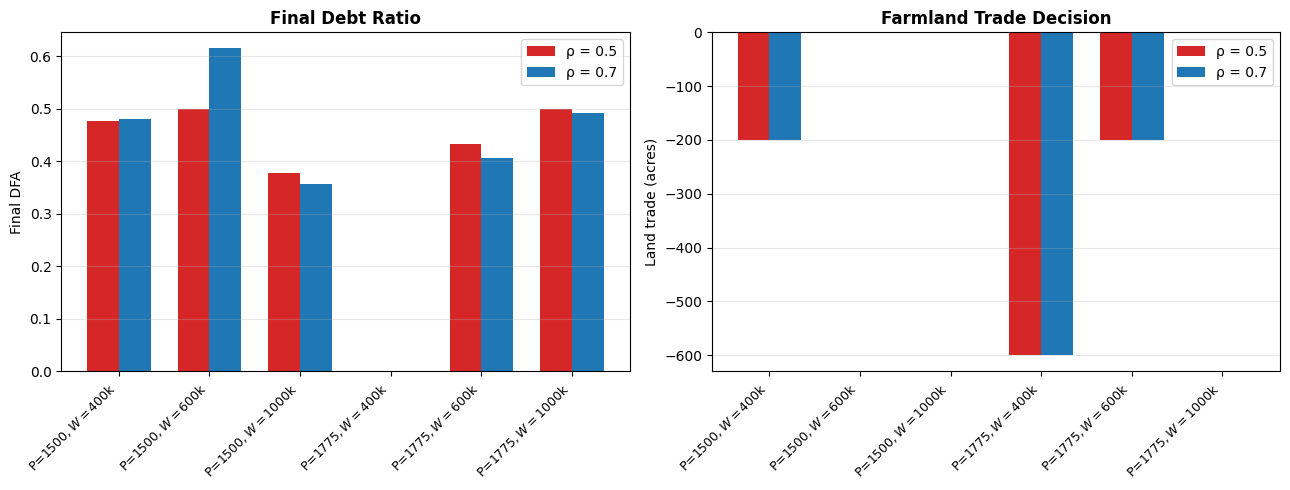

Saved LaTeX table: rho_dau_comparison.tex


In [17]:
# Sensitivity Analysis: compare rho/dau = 0.5 against the baseline rho/dau = 0.7
# Multiple scenarios like normal Table 7: prices and wealth levels

compare_daus = [0.5, float(cfg_table7_mutual.dau)]
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
reference_Rt = 365.0
reference_Lt = 600.0

comparison_rows = []

print("Computing sensitivity analysis for rho/dau = 0.5 and 0.7...")
print("Multiple scenarios across prices and wealth levels.\n")

for dau in compare_daus:
    if np.isclose(dau, float(cfg_table7_mutual.dau)):
        cfg_sensitivity = cfg_table7_mutual
        copt_sensitivity = copt_table7_mutual
        arrays_sens = arrays_m
        shock_nodes_sens = shock_nodes_m
        shock_weights_sens = shock_weights_m
    else:
        cfg_sensitivity = MutualFundConfig()
        cfg_sensitivity.dau = float(dau)
        cfg_sensitivity.Ee = (0.0, 0.0, 0.0)
        cfg_sensitivity.var_cov = (
            (0.030186, 0.0, 0.0),
            (0.0, 0.017292, 0.0),
            (0.0, 0.0, 0.026941),
        )
        cache_key_sens = (
            cfg_sensitivity.n,
            cfg_sensitivity.q,
            cfg_sensitivity.q2,
            cfg_sensitivity.m,
            cfg_sensitivity.T,
            cfg_sensitivity.t1,
            cfg_sensitivity.theta,
            cfg_sensitivity.b,
            cfg_sensitivity.dau,
            bool(cfg_sensitivity.CRRA),
            cfg_sensitivity.Ee,
            cfg_sensitivity.var_cov,
        )
        if cache_key_sens not in _mutual_copt_cache:
            print(f"  Solving for rho/dau={dau:.1f}...")
            _mutual_copt_cache[cache_key_sens] = solve_mutual_coefficients(cfg_sensitivity)
        copt_sensitivity = _mutual_copt_cache[cache_key_sens]
        arrays_sens = build_model_arrays(cfg_sensitivity)
        shock_nodes_sens, shock_weights_sens = gauss_hermite_multinormal(
            arrays_sens["m"], arrays_sens["Ee"], arrays_sens["VarCov"]
        )

    for price in prices:
        for wealth in wealth_levels:
            state = np.array([[reference_Rt, price, reference_Lt, wealth]], dtype=float)
            x_opt, xm_opt, _ = mutual_vmaxh(
                state,
                copt_sensitivity[:, 0],
                0,
                cfg_sensitivity,
                arrays_sens,
                shock_nodes_sens,
                shock_weights_sens,
            )
            x_star = float(x_opt[0])
            xm_star = float(xm_opt[0])
            comparison_rows.append({
                "rho/dau": f"{dau:.1f}",
                "Price": int(price),
                "Wealth": int(wealth),
                "Initial DFA": debt_to_farm_asset_ratio(price, reference_Lt, wealth),
                "Farmland trade (acres)": x_star,
                "Mutual fund investment ($)": xm_star,
                "Final DFA": resulting_dfa_after_trade(price, reference_Lt, wealth, x_star, xm_star),
            })

comparison_df = pd.DataFrame(comparison_rows)

display_table = comparison_df.copy()
display_table["Price"] = display_table["Price"].map(lambda v: f"${v:,.0f}")
display_table["Wealth"] = display_table["Wealth"].map(lambda v: f"${v:,.0f}")
display_table["Initial DFA"] = display_table["Initial DFA"].map(lambda v: f"{v:.3f}")
display_table["Farmland trade (acres)"] = display_table["Farmland trade (acres)"].map(lambda v: f"{v:,.0f}")
display_table["Mutual fund investment ($)"] = display_table["Mutual fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table["Final DFA"] = display_table["Final DFA"].map(lambda v: f"{v:.3f}")

print("=" * 100)
print("Sensitivity Analysis: rho/dau = 0.5 vs 0.7")
print("=" * 100)
display(display_table)

# Create grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Final DFA comparison
plot_data = comparison_df.pivot_table(
    index=["Price", "Wealth"],
    columns="rho/dau",
    values="Final DFA"
).reset_index()
x_labels = [f"P=${int(p)}, W=${int(w)//1000}k" for p, w in zip(plot_data["Price"], plot_data["Wealth"])]
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, plot_data["0.5"], width, label="ρ = 0.5", color="#d62728")
axes[0].bar(x_pos + width/2, plot_data["0.7"], width, label="ρ = 0.7", color="#1f77b4")
axes[0].set_title("Final Debt Ratio", fontweight="bold")
axes[0].set_ylabel("Final DFA")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Farmland trade comparison
plot_data2 = comparison_df.pivot_table(
    index=["Price", "Wealth"],
    columns="rho/dau",
    values="Farmland trade (acres)"
).reset_index()

axes[1].bar(x_pos - width/2, plot_data2["0.5"], width, label="ρ = 0.5", color="#d62728")
axes[1].bar(x_pos + width/2, plot_data2["0.7"], width, label="ρ = 0.7", color="#1f77b4")
axes[1].set_title("Farmland Trade Decision", fontweight="bold")
axes[1].set_ylabel("Land trade (acres)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("rho_dau_comparison.png", dpi=300, bbox_inches="tight")
print("\nSaved figure: rho_dau_comparison.png")
plt.show()

latex_table = display_table.rename(columns={
    "rho/dau": r"$\rho$",
    "Price": "Price",
    "Wealth": "Wealth",
    "Initial DFA": "Initial DFA",
    "Farmland trade (acres)": "Land trade",
    "Mutual fund investment ($)": "MF invest.",
    "Final DFA": "Final DFA",
})
latex_str = latex_table.to_latex(
    index=False,
    escape=False,
    column_format="ccccccc",
    caption="Sensitivity Analysis: Effect of lowering credit limit parameter $\rho$ from 0.7 to 0.5",
    label="tab:rho_dau_sensitivity",
)
tex_path = "rho_dau_comparison.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)
print(f"Saved LaTeX table: {tex_path}")

Computing CRRA vs CARA utility comparison...
Using baseline rho/dau = 0.7 for both.
CRRA theta = 1; CARA theta = 1/W_ref with W_ref=$600,000 -> 1.66667e-06

  Solving for CARA utility...
CRRA vs CARA Utility Comparison (rho/dau = 0.7, CARA calibrated at W_ref)


,Utility,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,CRRA,"$1,500","$400,000",0.605,-200,"49,330",0.481
1,CRRA,"$1,500","$600,000",0.408,0,"221,985",0.627
2,CRRA,"$1,500","$1,000,000",0.013,0,"347,990",0.357
3,CRRA,"$1,775","$400,000",0.658,-600,"400,000",0.000
4,CRRA,"$1,775","$600,000",0.487,-200,"183,150",0.465
5,CRRA,"$1,775","$1,000,000",0.144,0,"487,088",0.561
6,CARA,"$1,500","$400,000",0.605,-600,"400,000",0.000
7,CARA,"$1,500","$600,000",0.408,-600,"600,000",0.000
8,CARA,"$1,500","$1,000,000",0.013,-600,"1,000,000",0.000
9,CARA,"$1,775","$400,000",0.658,-600,"400,000",0.000



Saved figure: crra_cara_comparison.png


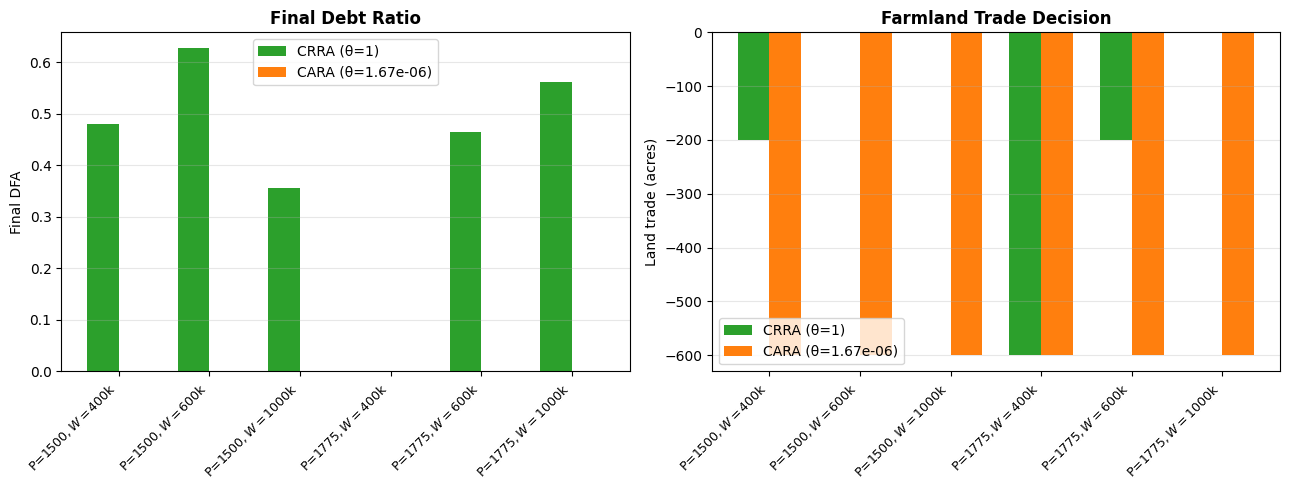

Saved LaTeX table: crra_cara_comparison.tex


In [29]:
# CRRA vs CARA Utility Comparison
# Compare risk preferences with CARA calibrated to match CRRA(log) ARA at a reference wealth.

compare_crra = [True, False]  # True=CRRA, False=CARA
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
reference_Rt = 365.0
reference_Lt = 600.0

# Comparable calibration: match absolute risk aversion at W_ref
# CRRA with theta=1 (log utility) has ARA = 1/W, CARA has ARA = theta.
cara_ref_wealth = 600_000.0
theta_crra = 1.0
theta_cara = 1.0 / cara_ref_wealth

crra_cara_rows = []

print("Computing CRRA vs CARA utility comparison...")
print("Using baseline rho/dau = 0.7 for both.")
print(f"CRRA theta = {theta_crra:.6g}; CARA theta = 1/W_ref with W_ref=${cara_ref_wealth:,.0f} -> {theta_cara:.6g}\n")

for use_crra in compare_crra:
    cfg_utility = MutualFundConfig()
    cfg_utility.CRRA = use_crra
    cfg_utility.theta = theta_crra if use_crra else theta_cara
    cfg_utility.Ee = (0.0, 0.0, 0.0)
    cfg_utility.var_cov = (
        (0.030186, 0.0, 0.0),
        (0.0, 0.017292, 0.0),
        (0.0, 0.0, 0.026941),
    )

    cache_key_utility = (
        cfg_utility.n,
        cfg_utility.q,
        cfg_utility.q2,
        cfg_utility.m,
        cfg_utility.T,
        cfg_utility.t1,
        cfg_utility.theta,
        cfg_utility.b,
        cfg_utility.dau,
        bool(cfg_utility.CRRA),
        cfg_utility.Ee,
        cfg_utility.var_cov,
    )

    if cache_key_utility not in _mutual_copt_cache:
        utility_label = "CRRA" if use_crra else "CARA"
        print(f"  Solving for {utility_label} utility...")
        _mutual_copt_cache[cache_key_utility] = solve_mutual_coefficients(cfg_utility)

    copt_utility = _mutual_copt_cache[cache_key_utility]
    arrays_utility = build_model_arrays(cfg_utility)
    shock_nodes_utility, shock_weights_utility = gauss_hermite_multinormal(
        arrays_utility["m"], arrays_utility["Ee"], arrays_utility["VarCov"]
    )

    for price in prices:
        for wealth in wealth_levels:
            state = np.array([[reference_Rt, price, reference_Lt, wealth]], dtype=float)
            x_opt, xm_opt, _ = mutual_vmaxh(
                state,
                copt_utility[:, 0],
                0,
                cfg_utility,
                arrays_utility,
                shock_nodes_utility,
                shock_weights_utility,
            )
            x_star = float(x_opt[0])
            xm_star = float(xm_opt[0])
            crra_cara_rows.append({
                "Utility": "CRRA" if use_crra else "CARA",
                "Price": int(price),
                "Wealth": int(wealth),
                "Initial DFA": debt_to_farm_asset_ratio(price, reference_Lt, wealth),
                "Farmland trade (acres)": x_star,
                "Mutual fund investment ($)": xm_star,
                "Final DFA": resulting_dfa_after_trade(price, reference_Lt, wealth, x_star, xm_star),
            })

crra_cara_df = pd.DataFrame(crra_cara_rows)

display_crra_cara = crra_cara_df.copy()
display_crra_cara["Price"] = display_crra_cara["Price"].map(lambda v: f"${v:,.0f}")
display_crra_cara["Wealth"] = display_crra_cara["Wealth"].map(lambda v: f"${v:,.0f}")
display_crra_cara["Initial DFA"] = display_crra_cara["Initial DFA"].map(lambda v: f"{v:.3f}")
display_crra_cara["Farmland trade (acres)"] = display_crra_cara["Farmland trade (acres)"].map(lambda v: f"{v:,.0f}")
display_crra_cara["Mutual fund investment ($)"] = display_crra_cara["Mutual fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_crra_cara["Final DFA"] = display_crra_cara["Final DFA"].map(lambda v: f"{v:.3f}")

print("=" * 100)
print("CRRA vs CARA Utility Comparison (rho/dau = 0.7, CARA calibrated at W_ref)")
print("=" * 100)
display(display_crra_cara)

# Create grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Final DFA comparison
plot_data = crra_cara_df.pivot_table(
    index=["Price", "Wealth"],
    columns="Utility",
    values="Final DFA"
).reset_index()
x_labels = [f"P=${int(p)}, W=${int(w)//1000}k" for p, w in zip(plot_data["Price"], plot_data["Wealth"])]
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, plot_data["CRRA"], width, label=f"CRRA (θ={theta_crra:g})", color="#2ca02c")
axes[0].bar(x_pos + width/2, plot_data["CARA"], width, label=f"CARA (θ={theta_cara:.2e})", color="#ff7f0e")
axes[0].set_title("Final Debt Ratio", fontweight="bold")
axes[0].set_ylabel("Final DFA")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Farmland trade comparison
plot_data2 = crra_cara_df.pivot_table(
    index=["Price", "Wealth"],
    columns="Utility",
    values="Farmland trade (acres)"
).reset_index()

axes[1].bar(x_pos - width/2, plot_data2["CRRA"], width, label=f"CRRA (θ={theta_crra:g})", color="#2ca02c")
axes[1].bar(x_pos + width/2, plot_data2["CARA"], width, label=f"CARA (θ={theta_cara:.2e})", color="#ff7f0e")
axes[1].set_title("Farmland Trade Decision", fontweight="bold")
axes[1].set_ylabel("Land trade (acres)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("crra_cara_comparison.png", dpi=300, bbox_inches="tight")
print("\nSaved figure: crra_cara_comparison.png")
plt.show()

latex_table_crra = display_crra_cara.rename(columns={
    "Utility": "Utility",
    "Price": "Price",
    "Wealth": "Wealth",
    "Initial DFA": "Initial DFA",
    "Farmland trade (acres)": "Land trade",
    "Mutual fund investment ($)": "MF invest.",
    "Final DFA": "Final DFA",
})
latex_str_crra = latex_table_crra.to_latex(
    index=False,
    escape=False,
    column_format="cccccccc",
    caption="Utility Function Comparison: CRRA vs CARA preferences on optimal decisions (CARA calibrated by ARA match at W_ref)",
    label="tab:crra_cara_comparison",
)
tex_path_crra = "crra_cara_comparison.tex"
with open(tex_path_crra, "w") as f:
    f.write(latex_str_crra)
print(f"Saved LaTeX table: {tex_path_crra}")

In [23]:
# Diagnostic: inspect CRRA vs CARA results and flag odd rows
if 'crra_cara_df' in globals():
    df = crra_cara_df.copy()
    # Show raw numeric values for inspection
    pd.set_option('display.float_format', lambda x: f"{x:.6f}")
    print('Full CRRA/CARA table (raw values):')
    display(df.reset_index(drop=True))

    # Flag zero trades/investments
    df['FT_zero'] = np.isclose(df['Farmland trade (acres)'], 0.0)
    df['MF_zero'] = np.isclose(df['Mutual fund investment ($)'], 0.0)

    print('\nRows with no land trade or no mutual-fund investment:')
    display(df[(df['FT_zero']) | (df['MF_zero'])][['Utility','Price','Wealth','Farmland trade (acres)','Mutual fund investment ($)','Final DFA','FT_zero','MF_zero']])

    # Show specific rows 6,7,11 (1-based indexing) if present
    for r in [6,7,11]:
        idx = r - 1
        if idx < len(df):
            print(f"\nRow {r} (1-based):")
            display(df.iloc[[idx]][['Utility','Price','Wealth','Farmland trade (acres)','Mutual fund investment ($)','Final DFA']])
else:
    print('crra_cara_df not found in kernel. Run the CRRA/CARA comparison cell first.')


Full CRRA/CARA table (raw values):


,Utility,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,CRRA,1500,400000,0.605289,-200.000000,49330.000000,0.480950
1,CRRA,1500,600000,0.407934,0.000000,221985.000000,0.626983
2,CRRA,1500,1000000,0.013223,0.000000,347990.000000,0.356611
3,CRRA,1775,400000,0.657681,-600.000000,400000.000000,0.000000
4,CRRA,1775,600000,0.486521,-200.000000,183150.000000,0.464891
5,CRRA,1775,1000000,0.144202,0.000000,487087.500000,0.561050
6,CARA,1500,400000,0.605289,0.000000,0.000000,0.605289
7,CARA,1500,600000,0.407934,0.000000,0.000000,0.407934
8,CARA,1500,1000000,0.013223,-69.998419,182862.049787,0.087173
9,CARA,1775,400000,0.657681,-186.610692,39619.324237,0.552364



Rows with no land trade or no mutual-fund investment:


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA,FT_zero,MF_zero
1,CRRA,1500,600000,0.000000,221985.000000,0.626983,True,False
2,CRRA,1500,1000000,0.000000,347990.000000,0.356611,True,False
5,CRRA,1775,1000000,0.000000,487087.500000,0.561050,True,False
6,CARA,1500,400000,0.000000,0.000000,0.605289,True,True
7,CARA,1500,600000,0.000000,0.000000,0.407934,True,True
10,CARA,1775,600000,-200.000000,0.000000,0.229782,False,True



Row 6 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
5,CRRA,1775,1000000,0.000000,487087.500000,0.561050



Row 7 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
6,CARA,1500,400000,0.000000,0.000000,0.605289



Row 11 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
10,CARA,1775,600000,-200.000000,0.000000,0.229782


In [25]:
# Diagnostic grid search for CARA problematic cases (use cached copt lookup)
from itertools import product

if 'crra_cara_df' in globals():
    cases = [
        {'Price':1500.0,'Wealth':400_000.0},
        {'Price':1500.0,'Wealth':600_000.0},
        {'Price':1775.0,'Wealth':600_000.0},
    ]
    use_crra = False
    theta = 1.0
    b = 60000.0
    dau = 0.7

    # Find matching cached copt
    cache_key_utility = None
    for k in _mutual_copt_cache.keys():
        try:
            if k[6] == theta and k[7] == b and k[8] == dau and (k[9] is False or k[9] == use_crra):
                cache_key_utility = k
                break
        except Exception:
            continue
    if cache_key_utility is None:
        raise RuntimeError('No matching cached copt found for CARA settings')

    copt_utility = _mutual_copt_cache[cache_key_utility]
    arrays_utility = build_model_arrays(MutualFundConfig())
    shock_nodes_utility, shock_weights_utility = gauss_hermite_multinormal(arrays_utility['m'], arrays_utility['Ee'], arrays_utility['VarCov'])

    for case in cases:
        P = case['Price']
        W = case['Wealth']
        state = np.array([[reference_Rt, P, reference_Lt, W]], dtype=float)
        xl, xu = mutual_bounds_x(state, MutualFundConfig())
        trade_grid = np.linspace(xl[0], xu[0], num=9)
        best_val = -1e99
        best_control = (0.0, 0.0)
        for tx in trade_grid:
            tx_arr = np.array([tx])
            xml, xmu = mutual_bounds_xm(state, tx_arr, MutualFundConfig())
            xm_grid = np.linspace(xml[0], xmu[0], num=9)
            for xm in xm_grid:
                controls = np.array([[tx, xm]])
                val = mutual_value_function(state, copt_utility, 0, controls, MutualFundConfig(), arrays_utility, shock_nodes_utility, shock_weights_utility)[0]
                if val > best_val:
                    best_val = float(val)
                    best_control = (float(tx), float(xm))
        zero_controls = np.array([[0.0, 0.0]])
        zero_val = mutual_value_function(state, copt_utility, 0, zero_controls, MutualFundConfig(), arrays_utility, shock_nodes_utility, shock_weights_utility)[0]
        print(f"Case P={int(P)}, W={int(W)} (CARA): best_val={best_val:.6f} at control={best_control}; zero_val={zero_val:.6f}")
        if np.isclose(best_control[0], 0.0) and np.isclose(best_control[1], 0.0):
            print("  -> Grid search confirms zero control is best within sampled bounds.")
        else:
            print("  -> Grid search found a better control; consider using finer grid or inspecting bounds.")
else:
    print('crra_cara_df not available; run comparison cell first.')


ValueError: operands could not be broadcast together with shapes (27,3) (1,2) 

In [24]:
# Quick inspect cache keys and shapes
for k, v in _mutual_copt_cache.items():
    try:
        print(k, np.shape(v))
    except Exception as e:
        print('key', k, 'error:', e)


((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, np.float64(0.3), True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.5, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 41, 25, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, False, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)


In [23]:
from time import perf_counter

# Profile where time goes when q and q2 are large: full value evaluation vs search overhead.
cfg_bottleneck = MutualFundConfig()
cfg_bottleneck.CRRA = False
cfg_bottleneck.Ee = (0.0, 0.0, 0.0)
cfg_bottleneck.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)
cfg_bottleneck.n = (7, 7, 5, 21)
cfg_bottleneck.q = 41
cfg_bottleneck.q2 = 25
cfg_bottleneck.qf = 21
cfg_bottleneck.m = (3, 3, 3)
cfg_bottleneck.T = 19
cfg_bottleneck.t1 = 1
cfg_bottleneck.search_mode = 'vectorized'
cfg_bottleneck.value_backend = 'numba'
cfg_bottleneck.q_batch = 4
cfg_bottleneck.q_batch_max_rows = 100_000

arrays_bottleneck = build_model_arrays(cfg_bottleneck)
shock_nodes_bottleneck, shock_weights_bottleneck = gauss_hermite_multinormal(arrays_bottleneck['m'], arrays_bottleneck['Ee'], arrays_bottleneck['VarCov'])
state_nodes_bottleneck = [
    uniform_nodes(int(arrays_bottleneck['n'][d]), float(arrays_bottleneck['smin'][d]), float(arrays_bottleneck['smax'][d]))
    for d in range(len(arrays_bottleneck['n']))
]
state_grid_bottleneck = cartesian_grid(state_nodes_bottleneck)
active_states_bottleneck = state_grid_bottleneck[state_grid_bottleneck[:, 3] > 1.0]
sample_states = active_states_bottleneck[:256]

if _value_backend(cfg_bottleneck) == 'numba':
    _ = mutual_vmaxh(
        sample_states[:4], None, cfg_bottleneck.T, cfg_bottleneck, arrays_bottleneck, shock_nodes_bottleneck, shock_weights_bottleneck
    )

# 1) Full evaluation on a representative sample.
t0 = perf_counter()
x_full, xm_full, v_full = mutual_vmaxh(
    sample_states, None, cfg_bottleneck.T, cfg_bottleneck, arrays_bottleneck, shock_nodes_bottleneck, shock_weights_bottleneck
 )
t_full = perf_counter() - t0

# 2) Search overhead only: monkeypatch the value function to a cheap zero-returning stub.
real_mutual_value_function = mutual_value_function
def _dummy_mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights):
    return np.zeros(np.asarray(state).shape[0], dtype=float)

mutual_value_function = _dummy_mutual_value_function
t0 = perf_counter()
x_dummy, xm_dummy, v_dummy = mutual_vmaxh(
    sample_states, None, cfg_bottleneck.T, cfg_bottleneck, arrays_bottleneck, shock_nodes_bottleneck, shock_weights_bottleneck
 )
t_dummy = perf_counter() - t0
mutual_value_function = real_mutual_value_function

# 3) Direct value-function cost for one candidate batch.
controls = np.column_stack([
    np.zeros(sample_states.shape[0], dtype=float),
    np.zeros(sample_states.shape[0], dtype=float),
])
t0 = perf_counter()
v_direct = mutual_value_function(
    sample_states, None, cfg_bottleneck.T, controls, cfg_bottleneck, arrays_bottleneck, shock_nodes_bottleneck, shock_weights_bottleneck
 )
t_vfunc = perf_counter() - t0

print('Bottleneck probe on a 256-state sample')
print(f'full mutual_vmaxh        : {t_full:.4f} s')
print(f'search overhead only     : {t_dummy:.4f} s')
print(f'direct mutual_value_function: {t_vfunc:.4f} s')
print(f'search/full ratio        : {t_dummy / max(t_full, 1e-12):.3f}')
print(f'value/full ratio         : {t_vfunc / max(t_full, 1e-12):.3f}')
print(f'max |x diff| dummy vs full: {np.max(np.abs(x_dummy - x_full)):.6g}')
print(f'max |xm diff| dummy vs full: {np.max(np.abs(xm_dummy - xm_full)):.6g}')
print(f'max |v diff| dummy vs full: {np.max(np.abs(v_dummy - v_full)):.6g}')
print(f'q={cfg_bottleneck.q}, q2={cfg_bottleneck.q2}, states={sample_states.shape[0]}')

Bottleneck probe on a 256-state sample
full mutual_vmaxh        : 0.0906 s
search overhead only     : 0.0048 s
direct mutual_value_function: 0.0001 s
search/full ratio        : 0.053
value/full ratio         : 0.001
max |x diff| dummy vs full: 1600
max |xm diff| dummy vs full: 0
max |v diff| dummy vs full: 1
q=41, q2=25, states=256


In [15]:
import gc


def cleanup_mutual_workspace(drop_cache=False, drop_benchmark=False):
    """Release large notebook objects after a run.

    By default this only clears the tables and run outputs from the most
    recent Table 8 / formatting cells. Pass drop_benchmark=True if you also
    want to release the profiling arrays and benchmark outputs.
    """
    names_to_delete = [
        "states",
        "summary_rows",
        "mutual_estimates_df",
        "table_display",
        "timing_df",
        "table8_step_timing",
        "display_table",
        "display_table7_with_mutual",
        "display_crra_cara",
        "crra_cara_df",
        "comparison_df",
    ]

    if drop_benchmark:
        names_to_delete.extend([
            "results",
            "baseline",
            "x_mode",
            "xm_mode",
            "v_mode",
            "x_full",
            "xm_full",
            "v_full",
            "x_dummy",
            "xm_dummy",
            "v_dummy",
            "v_direct",
            "sample_states",
            "state_grid_bottleneck",
            "active_states_bottleneck",
            "arrays_bottleneck",
            "shock_nodes_bottleneck",
            "shock_weights_bottleneck",
        ])

    for name in names_to_delete:
        if name in globals():
            del globals()[name]

    plt.close("all")

    if drop_cache and "_mutual_copt_cache" in globals():
        _mutual_copt_cache.clear()

    gc.collect()
    print("Notebook cleanup complete.")
